In [41]:
import cv2
from matplotlib import pyplot as plt
from shared.dataset import get_train_dataset_directory

image = cv2.cvtColor(cv2.cvtColor(cv2.imread('assets/white-circle.jpeg'), cv2.COLOR_BGR2RGB), cv2.COLOR_BGR2GRAY).astype(np.float64)

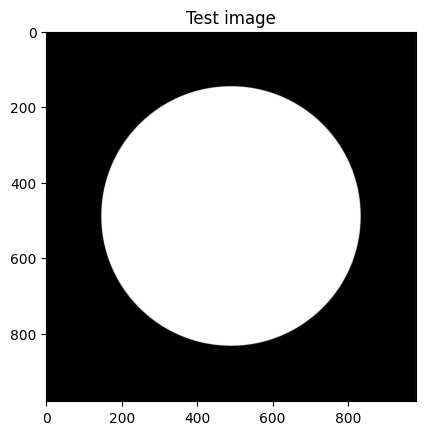

In [42]:
plt.imshow(image, cmap="gray")
plt.title('Test image')
plt.show()

| X Kernel | Y Kernel |
| :---: | :---: |
| $
\begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}
$ | $
\begin{bmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
1 & 2 & 1
\end{bmatrix}
$ |


In [43]:
import numpy as np

x_kernel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)
y_kernel = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float64)

height, width = image.shape
image_normalized = image / 255.0
gradient_x = np.zeros_like(image_normalized, dtype=np.float64)
gradient_y = np.zeros_like(image_normalized, dtype=np.float64)

for h in range(1, height - 1):
    for w in range(1, width - 1):
        region = image_normalized[h - 1 : h + 2, w - 1 : w + 2]
        gradient_x[h, w] = np.sum(region * x_kernel)
        gradient_y[h, w] = np.sum(region * y_kernel)

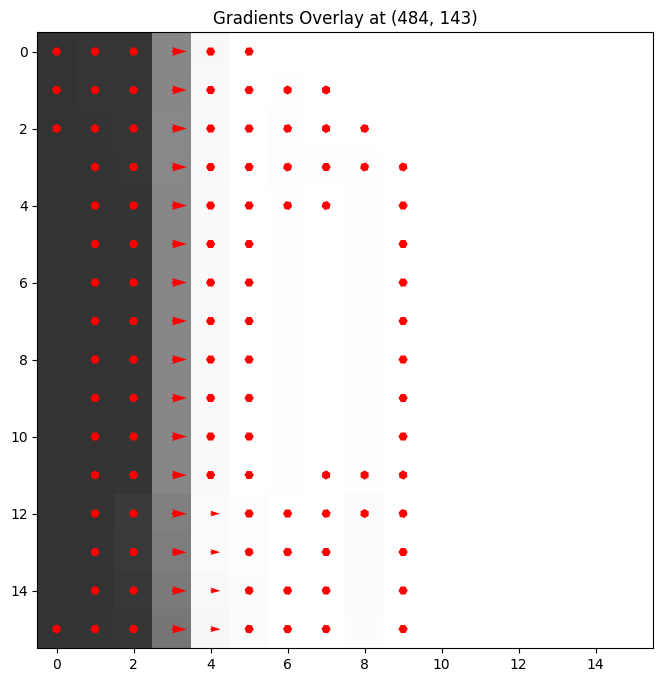

In [44]:
def plot_gradient_quiver(image, gx, gy, start_row, start_col, size=8, threshold=0.01):
    # Extract the patch from the image and the pre-computed gradients
    region = image[start_row : start_row + size, start_col : start_col + size]
    patch_gx = gx[start_row : start_row + size, start_col : start_col + size]
    patch_gy = gy[start_row : start_row + size, start_col : start_col + size]
    
    h, w = region.shape
    X, Y = np.meshgrid(np.arange(w), np.arange(h))
    
    mag = np.sqrt(patch_gx**2 + patch_gy**2)
    mask = mag > threshold
    
    plt.figure(figsize=(8, 8))
    plt.imshow(region, cmap='gray', origin='upper', alpha=0.8)
    
    # Use patch_gx/patch_gy here!
    plt.quiver(X[mask], Y[mask], patch_gx[mask], -patch_gy[mask], 
               color='red', angles='xy', scale_units='xy', scale=10, width=0.015)

    plt.title(f"Gradients Overlay at ({start_row}, {start_col})")
    plt.show()
mag = np.sqrt(gradient_x**2 + gradient_y**2)
nonzero_coords = np.argwhere(mag > (np.max(mag) * 0.5))

# Pick the first one found
if len(nonzero_coords) > 0:
    start_row, start_col = nonzero_coords[len(nonzero_coords)//2] # Middle of the edge list
    # Subtract half your 'size' to center the edge in your plot
    plot_gradient_quiver(image_normalized, gradient_x, gradient_y, start_row-4, start_col-4, size=16)